# Visualiza las zonas de sombra del eclipse de 2026

## 0 Introducción

En este notebook se describe el código en Python necesario para la realización del ejercicio de datos que muestra las **zonas de sombra por relieve** para el eclipse de 2026 sobre la península ibérica.

Los pasos a ejecutar son los siguientes:
- **Lectura del fichero** de entrada
- **Unión de los diferentes polígonos** que componen las zonas de sombra del fichero de entrada
- **Creación de un dataframe** para alojar la forma resultante.
- **Invertir el orden de registro** de los puntos del polígono resultante.
- **Creación de un mapa** en Python con los **resultados parciales y definitivos** sobre el municipio estudiado
- **Exportar** la zona de sombra como un **fichero .geojson**

Tras la realización de estos pasos seremos capaces de familiarizarnos con el **formato .GPKG**, la estructuración de datos georreferenciados en **formato pandas y geopandas**, las herramientas básicas para realizar **una unión de polígonos** y de formas geométricas y finalmente el uso de librerías de Python para **crear mapas** y hacer una rápida comprobación de los resultados de nuestras operaciones.   

## 1. Proceso de desarrollo

En esta sección veremos las diferentes etapas a cubrir para llegar desde el fichero comprimido original hasta desplegar mapas en diversas plataformas con la información relevante del eclipse total.

### 1.1 Lectura de un fichero GPKG

El primer paso es cargar las librerías necesarias de Python para poder manipular el fichero con lso datos. Para ello utilizaremos GeoPandas para estructurar los datos de entrada, Matplotlib para crear figuras, Cartopy para crear mapas, Numpy para operaciones numéricas básicas, Shapely para poder procesar las geometrías de los datos de origen y finalmente Pandas para exportar el resultado final en otros formatos.

   

In [ ]:
!pip install cartopy
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import shapely.geometry as geom
import pandas as pd
import io
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

Una vez hemos incorporado las librerías necesarias descargamos el fichero Eclipses.gpkg del CNIG con la información referente a la zona de sombra del eclipse, bien a través del enlace descrito en el ejercicio o desde el repositorio de Github. Una vez descargado subimos el fichero a través de la función .upload() del notebook:

In [ ]:
uploaded = files.upload()

Saving Eclipses.gpkg to Eclipses.gpkg


La lectura del archivo .GPKG la realizaremos con la ayuda de la librería GeopPandas  de Python. En primer lugar extraemos los nombres de las diferentes capas que están contenidas en el geopackage, haciendo un listado utilizando la función .list_layers.


In [ ]:
layers = gpd.list_layers('Eclipses.gpkg')
layers

,name,geometry_type
0,oscurez_standard_2026 — contour,Polygon
1,moon_shadow_2026_merged_18.291-18.567-2026-sim...,MultiPolygon
2,durtot_standard_2026 — contour,Polygon


La capa que nos interesa es "moon_shadow..." así que volcamos el contenido de esa capa en un dataframe de GeopPandas.

In [ ]:
package = gpd.read_file(r'./Eclipses.gpkg', layer=layers.values[1][0])

## 1.2 Unión de diferentes polígonos

Para tener una perspectiva global de todo el recorrido de la sombra a través de la península unimos todas las geometrías de cada intervalo temporal para tener una única forma geométrica. El resultado de la unión se muestra a continuación, todavía fuera de contexto.

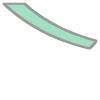

In [ ]:
item = package.geometry.unary_union
item

## 1.3 Creación de un dataframe

A continuación queremos crear un dataframe con ese polígono resultante. Para ello creamos un array con el nombre y la geometría como categorías e introducimos en la geometría el polígono resultante del paso anterior.

In [ ]:
data = {'name': ['Area1'], 'geometry': [item]}
data

{'name': ['Area1'],
 'geometry': [<POLYGON ((-8.933 47.142, -8.933 47.133, -8.925 47.133, -8.925 47.125, -8.91...>]}

Con esta lista de elementos creamos el dataframe

In [ ]:
df = pd.DataFrame(data)
df

,name,geometry
0,Area1,"POLYGON ((-8.9333333 47.1416667, -8.9333333 47..."


Y lo pasamos a geodataframe utilizando Geopandas, especificando de nuevo la geometría de forma explícita.

In [ ]:
gdf = gpd.GeoDataFrame(df, geometry='geometry')
gdf

,name,geometry
0,Area1,"POLYGON ((-8.93333 47.14167, -8.93333 47.13333..."


## 1.4 Identificación de límites

Identificamos a continuación los límites de la forma resultante para su posterior mapeado

In [ ]:
bounds = gdf.total_bounds
bounds

array([-16.5666667,  37.425    ,   7.3833333,  49.       ])

## 1.5 Inversión del orden de puntos

Y terminamos el procesado invirtiendo el orden de los puntos que crean la forma. Este paso puede parecer poco intuitivo, pero al ser una forma cerrada nos permite definir lo que es dentro y fuera de esa forma. Javascript depende del orden de los puntos para la definición de dentro y fuera y a veces es necesario reasignar ese orden en una u otra dirección.

In [ ]:
clockwise_item = gdf.reverse()
clockwise_item

,0
0,"POLYGON ((-8.93333 47.14167, -8.94167 47.14167..."


## 1.6 Exportar en formato geojson

El resultado lo exportamos en formato geojson para poder realizar mapas en otros soportes diferentes a Python, tales como Javascript.

In [ ]:
clockwise_item.to_file(r'./item_geojson.geojson', driver='GeoJSON')

## 1.7 Mapa del resultado

Python nos permite crear un mapa preliminar donde poder visualizar el resultado de la unión de los polígonos de sombra del eclipse utilizando la librería Cartopy

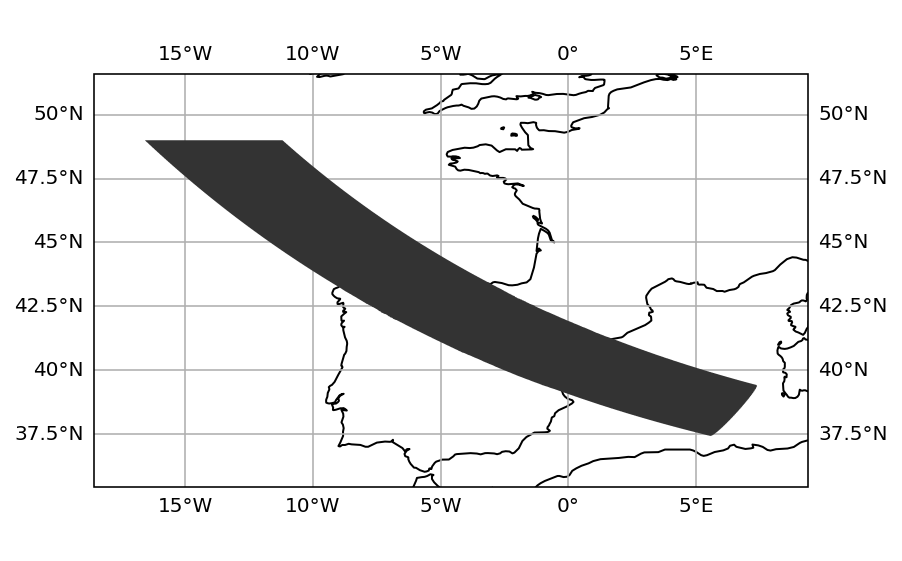

In [ ]:
fig,ax = plt.subplots(dpi=144, frameon=False)
plt.box(False)
plt.xticks([])
plt.yticks([])
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_geometries(gdf.geometry, crs=ccrs.PlateCarree(), edgecolor='none', facecolor='#333', zorder=5)
ax.set_extent([bounds[0]-2, bounds[2]+2, bounds[1]-2, bounds[3]+2])
ax.coastlines()
gl = ax.gridlines(draw_labels=True)
plt.show()